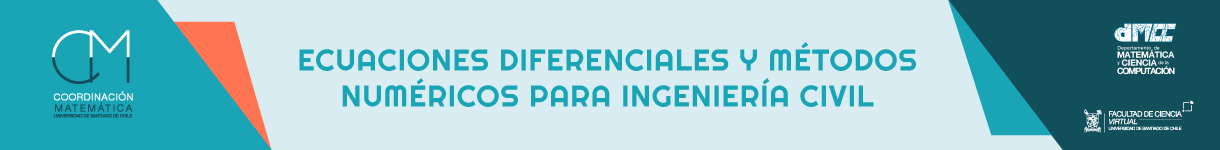


# **Semana 8**

- Sistemas de ecuaciones diferenciales lineales homogéneas.
- Forma matricial $\mathbf{X}' = A\mathbf{X}$.
- Valores y vectores propios como método de solución.
- Casos: valores propios reales distintos, complejos y repetidos.

In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
sp.init_printing(use_latex='mathjax')

#Recuerdo:

Un **sistema lineal homogéneo** de primer orden con coeficientes constantes se escribe como

$$
\begin{cases}
x_1' = a_{11}x_1 + a_{12}x_2 + \cdots + a_{1n}x_n \\
x_2' = a_{21}x_1 + a_{22}x_2 + \cdots + a_{2n}x_n \\
\quad \vdots \\
x_n' = a_{n1}x_1 + a_{n2}x_2 + \cdots + a_{nn}x_n
\end{cases}
$$

que en **forma matricial** se resume como

$$ \mathbf{X}'(t) = A\, \mathbf{X}(t), $$

donde $\mathbf{X}(t) = (x_1(t),\dots,x_n(t))^t$ es el vector de funciones incógnitas y $A \in \mathbb{R}^{n\times n}$ es la matriz de coeficientes (constante).

> <b>Idea clave (analogía con el caso escalar)</b>:
Para la ecuación escalar $x' = a x$ sabemos que la solución es $x(t) = c\, e^{at}$. Es natural, entonces, buscar soluciones del sistema de la forma
$$ \mathbf{X}(t) = \mathbf{v}\, e^{\lambda t}, $$
con $\mathbf{v}$ un vector constante no nulo y $\lambda$ un escalar.

Al reemplazar $\mathbf{X}=\mathbf{v}e^{\lambda t}$ en $\mathbf{X}'=A\mathbf{X}$ se obtiene $\lambda \mathbf{v} e^{\lambda t} = A\mathbf{v}\, e^{\lambda t}$, y como $e^{\lambda t}\neq 0$:

$$ A\mathbf{v} = \lambda \mathbf{v}. $$

Es decir, **$\lambda$ debe ser un valor propio de $A$ y $\mathbf{v}$ un vector propio asociado**. Resolver el sistema se reduce, entonces, a un problema de valores y vectores propios.

---

##**1. Definir la matriz del sistema y calcular sus valores propios**

####**Explicación**

* Usaremos `sympy` para trabajar de manera **simbólica** (exacta), evitando errores de redondeo.
* La matriz se define con `sp.Matrix`.
* El comando `A.eigenvals()` entrega los valores propios (con su multiplicidad) y `A.eigenvects()` entrega los valores propios junto con sus vectores propios asociados.

Consideremos el sistema $\mathbf{X}'=A\mathbf{X}$ con

$$ A = \begin{pmatrix} 1 & 2 \\ 4 & 3 \end{pmatrix}. $$

In [3]:
t = sp.Symbol('t', real=True)

# Matriz de coeficientes del sistema
A = sp.Matrix([[1, 2],
               [4, 3]])
A

⎡1  2⎤
⎢    ⎥
⎣4  3⎦

El **polinomio característico** de $A$ es $p(\lambda)=\det(A-\lambda I)$. Sus raíces son los valores propios.

In [4]:
lam = sp.Symbol('lambda')
p = (A - lam*sp.eye(2)).det()          # det(A - lambda I)
sp.Eq(sp.factor(p), 0)

(λ - 5)⋅(λ + 1) = 0

In [5]:
# Valores propios (diccionario: valor_propio : multiplicidad)
A.eigenvals()

{-1: 1, 5: 1}

##**2. Calcular los vectores propios**

Para cada valor propio $\lambda$ resolvemos $(A-\lambda I)\mathbf{v}=\mathbf{0}$. El comando `eigenvects()` retorna una lista de tuplas de la forma

$$ (\lambda,\; \text{multiplicidad},\; [\mathbf{v}_1, \mathbf{v}_2, \dots]) $$

In [6]:
A.eigenvects()

⎡⎛       ⎡⎡-1⎤⎤⎞  ⎛      ⎡⎡1/2⎤⎤⎞⎤
⎢⎜-1, 1, ⎢⎢  ⎥⎥⎟, ⎜5, 1, ⎢⎢   ⎥⎥⎟⎥
⎣⎝       ⎣⎣1 ⎦⎦⎠  ⎝      ⎣⎣ 1 ⎦⎦⎠⎦

##**3. Construir la solución general (valores propios reales distintos)**

####**Explicación**

Cuando $A$ (de tamaño $n\times n$) posee $n$ valores propios reales y distintos $\lambda_1,\dots,\lambda_n$, con vectores propios $\mathbf{v}_1,\dots,\mathbf{v}_n$, la **solución general** es

$$ \mathbf{X}(t) = c_1 \mathbf{v}_1 e^{\lambda_1 t} + c_2 \mathbf{v}_2 e^{\lambda_2 t} + \cdots + c_n \mathbf{v}_n e^{\lambda_n t}, $$

con $c_1,\dots,c_n$ constantes arbitrarias determinadas por las condiciones iniciales.

In [7]:
c1, c2 = sp.symbols('c1 c2')

# Extraemos valores y vectores propios
datos = A.eigenvects()
(lam1, _, [v1]) = datos[0]
(lam2, _, [v2]) = datos[1]

# Solución general X(t) = c1 v1 e^{lam1 t} + c2 v2 e^{lam2 t}
X = c1*v1*sp.exp(lam1*t) + c2*v2*sp.exp(lam2*t)
X = sp.simplify(X)
X

⎡⎛          6⋅t⎞    ⎤
⎢⎜      c₂⋅ℯ   ⎟  -t⎥
⎢⎜-c₁ + ───────⎟⋅ℯ  ⎥
⎢⎝         2   ⎠    ⎥
⎢                   ⎥
⎢⎛         6⋅t⎞  -t ⎥
⎣⎝c₁ + c₂⋅ℯ   ⎠⋅ℯ   ⎦

Escrito por componentes, si $\mathbf{X}=(x_1(t),x_2(t))^t$:

In [8]:
x1, x2 = sp.symbols('x1 x2', cls=sp.Function)
sp.Eq(sp.Symbol('x_1(t)'), X[0]), sp.Eq(sp.Symbol('x_2(t)'), X[1])

⎛        ⎛          6⋅t⎞                                ⎞
⎜        ⎜      c₂⋅ℯ   ⎟  -t          ⎛         6⋅t⎞  -t⎟
⎜x₁₍ₜ₎ = ⎜-c₁ + ───────⎟⋅ℯ  , x₂₍ₜ₎ = ⎝c₁ + c₂⋅ℯ   ⎠⋅ℯ  ⎟
⎝        ⎝         2   ⎠                                ⎠

##**4. Verificar la solución**

Una solución debe cumplir $\mathbf{X}'(t) - A\,\mathbf{X}(t) = \mathbf{0}$. Comprobémoslo simbólicamente.

In [ ]:
residuo = sp.simplify(X.diff(t) - A*X)
print("X'(t) - A X(t) =")
residuo

Como el residuo es el vector nulo, la solución encontrada satisface el sistema para **cualquier** valor de las constantes $c_1$ y $c_2$.

##**5. Resolver el sistema directamente con `dsolve`**

`sympy` también permite resolver el sistema de manera automática con `sp.dsolve`, entregándole la **lista de ecuaciones**. Sirve para contrastar con el método de valores propios.

In [ ]:
x1 = sp.Function('x1')(t)
x2 = sp.Function('x2')(t)

# Sistema x1' = x1 + 2 x2 ; x2' = 4 x1 + 3 x2
eq1 = sp.Eq(x1.diff(t), A[0,0]*x1 + A[0,1]*x2)
eq2 = sp.Eq(x2.diff(t), A[1,0]*x1 + A[1,1]*x2)

sol = sp.dsolve([eq1, eq2])
sol

Observa que la solución obtenida con `dsolve` es equivalente a la construida con valores y vectores propios (las constantes pueden estar nombradas de otra forma, por ejemplo $C_1, C_2$).

##**6. Problema de valor inicial (PVI)**

Resolvamos ahora el mismo sistema con condiciones iniciales
$$ x_1(0)=1, \qquad x_2(0)=0. $$

Podemos entregar las condiciones a `dsolve` mediante el argumento `ics` (un diccionario).

In [ ]:
ics = {x1.subs(t, 0): 1, x2.subs(t, 0): 0}
sol_pvi = sp.dsolve([eq1, eq2], ics=ics)
sol_pvi

También podemos resolver el PVI **a mano** determinando $c_1$ y $c_2$ a partir de $\mathbf{X}(0)=(1,0)^t$:

In [ ]:
# X(0) = c1 v1 + c2 v2 = (1,0)^t
X0 = X.subs(t, 0)
constantes = sp.solve([sp.Eq(X0[0], 1), sp.Eq(X0[1], 0)], [c1, c2])
constantes

In [ ]:
X_pvi = sp.simplify(X.subs(constantes))
print("Solución del PVI:")
X_pvi

##**7. Caso: valores propios complejos**

####**Explicación**

Si $A$ posee valores propios complejos conjugados $\lambda = \alpha \pm \beta i$ (con $\beta\neq 0$), las soluciones involucran senos y cosenos. Recordando la fórmula de Euler $e^{(\alpha+\beta i)t}=e^{\alpha t}(\cos\beta t + i\,\sin\beta t)$, la solución general **real** tiene la forma

$$ \mathbf{X}(t)=e^{\alpha t}\Big[ c_1\big(\mathbf{a}\cos\beta t - \mathbf{b}\sin\beta t\big) + c_2\big(\mathbf{a}\sin\beta t + \mathbf{b}\cos\beta t\big)\Big], $$

donde $\mathbf{v}=\mathbf{a}+i\mathbf{b}$ es un vector propio asociado a $\lambda=\alpha+\beta i$.

Consideremos

$$ A = \begin{pmatrix} 0 & -2 \\ 2 & 0 \end{pmatrix}. $$

In [ ]:
B = sp.Matrix([[0, -2],
               [2,  0]])
B.eigenvals()

In [ ]:
B.eigenvects()

Dejamos que `dsolve` entregue la solución general en términos reales (senos y cosenos):

In [ ]:
y1 = sp.Function('y1')(t)
y2 = sp.Function('y2')(t)
eqB1 = sp.Eq(y1.diff(t), B[0,0]*y1 + B[0,1]*y2)
eqB2 = sp.Eq(y2.diff(t), B[1,0]*y1 + B[1,1]*y2)
sp.dsolve([eqB1, eqB2])

##**8. Caso: valores propios repetidos**

####**Explicación**

Si $A$ tiene un valor propio $\lambda$ de multiplicidad $2$ pero **un solo** vector propio linealmente independiente $\mathbf{v}$ (matriz *defectuosa*), la solución general se construye con un **vector propio generalizado** $\mathbf{w}$ que resuelve $(A-\lambda I)\mathbf{w}=\mathbf{v}$:

$$ \mathbf{X}(t)=c_1\,\mathbf{v}\,e^{\lambda t} + c_2\big(\mathbf{v}\,t\,e^{\lambda t} + \mathbf{w}\,e^{\lambda t}\big). $$

Consideremos

$$ A = \begin{pmatrix} 3 & 1 \\ 0 & 3 \end{pmatrix}. $$

In [ ]:
C = sp.Matrix([[3, 1],
               [0, 3]])
C.eigenvals()

In [ ]:
# Observamos que solo hay un vector propio independiente
C.eigenvects()

Buscamos el vector propio generalizado $\mathbf{w}$ resolviendo $(A-\lambda I)\mathbf{w}=\mathbf{v}$:

In [ ]:
lamb = list(C.eigenvals().keys())[0]      # valor propio repetido
v = C.eigenvects()[0][2][0]               # vector propio
w1, w2 = sp.symbols('w1 w2')
w = sp.Matrix([w1, w2])

solw = sp.solve((C - lamb*sp.eye(2))*w - v, [w1, w2])
solw

El comando `dsolve` maneja este caso automáticamente. Observa la aparición del factor $t\,e^{\lambda t}$:

In [ ]:
z1 = sp.Function('z1')(t)
z2 = sp.Function('z2')(t)
eqC1 = sp.Eq(z1.diff(t), C[0,0]*z1 + C[0,1]*z2)
eqC2 = sp.Eq(z2.diff(t), C[1,0]*z1 + C[1,1]*z2)
sp.dsolve([eqC1, eqC2])

---

##**Ejercicios**

### Ejercicio 01

Considere el sistema $\mathbf{X}'=A\mathbf{X}$ con
$$ A = \begin{pmatrix} 2 & 3 \\ 2 & 1 \end{pmatrix}. $$

* a) Calcule los valores y vectores propios de $A$ usando `sympy`.
* b) Escriba la solución general.
* c) Verifique simbólicamente que su solución satisface $\mathbf{X}'-A\mathbf{X}=\mathbf{0}$.

### Ejercicio 02

Resuelva el problema de valor inicial
$$ \mathbf{X}'=\begin{pmatrix} -1 & 1 \\ 4 & -1 \end{pmatrix}\mathbf{X}, \qquad \mathbf{X}(0)=\begin{pmatrix} 1 \\ 2 \end{pmatrix}. $$

Resuélvalo de **dos formas**: usando `dsolve` con el argumento `ics`, y de manera manual determinando las constantes a partir de la condición inicial. Compare ambos resultados.

### Ejercicio 03

Para el sistema
$$ A = \begin{pmatrix} 1 & -2 \\ 2 & 1 \end{pmatrix}, $$
* a) Verifique que los valores propios son complejos conjugados.
* b) Obtenga la solución general real con `dsolve`.
* c) Grafique el retrato de fase. ¿El origen es un centro, una espiral atractora o una espiral repulsora? Justifique a partir del signo de la parte real de los valores propios.

### Ejercicio 04

Considere el sistema $3\times 3$
$$ A = \begin{pmatrix} 1 & 0 & 0 \\ 2 & -1 & 0 \\ 3 & 2 & 2 \end{pmatrix}. $$

* a) Calcule los valores propios y determine si son todos distintos.
* b) Construya la solución general $\mathbf{X}(t)=c_1\mathbf{v}_1 e^{\lambda_1 t}+c_2\mathbf{v}_2 e^{\lambda_2 t}+c_3\mathbf{v}_3 e^{\lambda_3 t}$.
* c) Verifique la solución con `dsolve`.

### Ejercicio 05

La matriz
$$ A = \begin{pmatrix} -2 & 1 \\ 0 & -2 \end{pmatrix} $$
posee un valor propio repetido.

* a) Compruebe, usando `eigenvects()`, que solo existe un vector propio linealmente independiente.
* b) Determine el vector propio generalizado $\mathbf{w}$ resolviendo $(A-\lambda I)\mathbf{w}=\mathbf{v}$.
* c) Escriba la solución general e identifique el término que contiene el factor $t\,e^{\lambda t}$.

### Ejercicio 06

**Aplicación.** Dos estanques conectados intercambian una sustancia. Las cantidades $x_1(t)$ y $x_2(t)$ (en gramos) satisfacen
$$ x_1' = -\tfrac{1}{2}x_1 + \tfrac{1}{4}x_2, \qquad x_2' = \tfrac{1}{2}x_1 - \tfrac{1}{4}x_2, $$
con $x_1(0)=10$ y $x_2(0)=0$.

* a) Escriba el sistema en forma matricial e identifique la matriz $A$.
* b) Resuelva el PVI con `sympy`.
* c) Grafique $x_1(t)$ y $x_2(t)$ para $t\in[0,10]$ (use `sp.lambdify` para pasar a funciones numéricas).
* d) ¿Hacia qué valores tienden $x_1$ y $x_2$ cuando $t\to\infty$? Relacione su respuesta con el valor propio nulo de $A$.